### Fade Margin (FM) Section — Calibrate on OOF, Validate on Test

This notebook calibrates fade margins (FM) for COST 231 MWM, MLR, kNN, RF, LightGBM, XGBoost, ANN, and RNN using Out-Of-Fold (OOF) residuals and validates them on the held-out test residuals.


#### Core & Data Libraries

In [ ]:
# Standard library
import os
import pickle
import time
from pathlib import Path

# Thread control: set before NumPy/SciPy/sklearn imports
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["NUMEXPR_MAX_THREADS"] = "1"

if os.path.isdir("/dev/shm"):
    os.environ.setdefault("JOBLIB_TEMP_FOLDER", "/dev/shm/joblib")

# Data and numerical computing
import numpy as np
import pandas as pd
import scipy.stats as sps

# Modeling and parallelism
from sklearn.mixture import GaussianMixture
from joblib import Parallel, delayed

# Plotting
import matplotlib.pyplot as plt

# Notebook display
from IPython.display import display

# Parallelism
N_JOBS = -1

# Global toggles
EXACT_BCA = False
BLOCK_BY_DEVICE = True
RANDOM_STATE = 42

# Fade-margin settings
P_GRID = [0.05, 0.02, 0.01]
HEURISTIC_FM_DB = 10.0
BOOTSTRAP_B = 1000

#### Load OOF Residuals

In [2]:
# Data locations
OOF_DIR  = "Residuals"
TEST_DIR = "Residuals"

# Candidate mappings (OOF)
CANDIDATE_OOF_FILES = {
    "MLR":      [f"{OOF_DIR}/residuals_MLR_oof.csv"],
    "COST 231 MWM": [f"{OOF_DIR}/residuals_PLM_COST231_MWM_oof.csv"],
    "KNN":      [f"{OOF_DIR}/residuals_KNN_oof.csv"],
    "RF":       [f"{OOF_DIR}/residuals_RF_oof.csv"],
    "LightGBM": [f"{OOF_DIR}/residuals_LGBM_oof.csv"],
    "XGBoost":  [f"{OOF_DIR}/residuals_XGB_oof.csv"],
    "ANN":      [f"{OOF_DIR}/residuals_ANN_oof.csv"],
    "RNN":      [f"{OOF_DIR}/residuals_RNN_oof.csv"],
}

# Candidate mappings (held-out test)
CANDIDATE_TEST_FILES = {
    "MLR":      [f"{TEST_DIR}/residuals_MLR_test.csv"],
    "COST 231 MWM": [f"{TEST_DIR}/residuals_PLM_COST231_MWM_test.csv"],
    "KNN":      [f"{TEST_DIR}/residuals_KNN_test.csv"],
    "RF":       [f"{TEST_DIR}/residuals_RF_test.csv"],
    "LightGBM": [f"{TEST_DIR}/residuals_LGBM_test.csv"],
    "XGBoost":  [f"{TEST_DIR}/residuals_XGB_test.csv"],
    "ANN":      [f"{TEST_DIR}/residuals_ANN_test.csv"],
    "RNN":      [f"{TEST_DIR}/residuals_RNN_test.csv"],
}

# Column detection candidates
TIME_COL_CANDS   = ["timestamp", "ts", "time", "datetime", "DateTime", "TIME"]
DEVICE_COL_CANDS = ["device_id", "device", "Device", "ed", "ED", "node", "Node"]
RESID_COL_CANDS  = ["resid_db", "residuals", "resid", "error", "epsilon"]

def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError("None of the candidate paths exist:\\n  " + "\\n  ".join(paths))

def _pick_residual_col(df):
    for c in RESID_COL_CANDS:
        if c in df.columns:
            return c
    raise KeyError("Residual column not found in dataframe.")

def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _time_sort(df):
    tc = _find_col(df, TIME_COL_CANDS)
    if tc is None:
        return df
    try:
        return df.sort_values(tc)
    except Exception:
        tmp = pd.to_datetime(df[tc], errors="coerce")
        return df.assign(_t=tmp).sort_values("_t").drop(columns=["_t"])

# Load OOF calibration residuals and matching held-out test residuals.
oof_residuals = {}     # model -> np.array
test_residuals = {}    # model -> np.array
oof_devices   = {}     # model -> device array or None
test_devices  = {}     # model -> device array or None
model_tags    = {}     # model -> tag from 'model' column if present

for fam, candidates in CANDIDATE_OOF_FILES.items():
    oof_path = _first_existing(candidates)
    df_oof = _time_sort(pd.read_csv(oof_path))
    res_col = _pick_residual_col(df_oof)
    eps_oof = df_oof[res_col].astype(float).to_numpy()
    oof_residuals[fam] = eps_oof

    dev_col_oof = _find_col(df_oof, DEVICE_COL_CANDS)
    oof_devices[fam] = df_oof[dev_col_oof].astype(str).to_numpy() if dev_col_oof else None

    if "model" in df_oof.columns and len(df_oof):
        model_tags[fam] = str(df_oof["model"].iloc[0])
    else:
        model_tags[fam] = fam

    test_path = _first_existing(CANDIDATE_TEST_FILES[fam])
    df_test = _time_sort(pd.read_csv(test_path))
    res_col_test = _pick_residual_col(df_test)
    eps_test = df_test[res_col_test].astype(float).to_numpy()
    test_residuals[fam] = eps_test

    dev_col_test = _find_col(df_test, DEVICE_COL_CANDS)
    test_devices[fam] = df_test[dev_col_test].astype(str).to_numpy() if dev_col_test else None

    print(f"[{fam}] OOF: {oof_path} (n={len(eps_oof)}) | TEST: {test_path} (n={len(eps_test)})")


[MLR] OOF: Residuals/residuals_MLR_oof.csv (n=1663627) | TEST: Residuals/residuals_MLR_test.csv (n=415907)
[COST 231 MWM] OOF: Residuals/residuals_PLM_COST231_MWM_oof.csv (n=1663627) | TEST: Residuals/residuals_PLM_COST231_MWM_test.csv (n=415907)
[KNN] OOF: Residuals/residuals_KNN_oof.csv (n=1663627) | TEST: Residuals/residuals_KNN_test.csv (n=415907)
[RF] OOF: Residuals/residuals_RF_oof.csv (n=1663627) | TEST: Residuals/residuals_RF_test.csv (n=415907)
[LightGBM] OOF: Residuals/residuals_LGBM_oof.csv (n=1663627) | TEST: Residuals/residuals_LGBM_test.csv (n=415907)
[XGBoost] OOF: Residuals/residuals_XGB_oof.csv (n=1663627) | TEST: Residuals/residuals_XGB_test.csv (n=415907)
[ANN] OOF: Residuals/residuals_ANN_oof.csv (n=1663627) | TEST: Residuals/residuals_ANN_test.csv (n=415907)
[RNN] OOF: Residuals/residuals_RNN_oof.csv (n=1663582) | TEST: Residuals/residuals_RNN_test.csv (n=415898)


#### FM Calibration Utilities

In [3]:
# ACF / block length utilities
def acf(x, max_lag=None):
    x = np.asarray(x, float)
    x = x - x.mean()
    n = len(x)
    if n < 3:
        max_lag = 1
    if max_lag is None:
        max_lag = min(200, n - 2) if n > 2 else 1
    c = np.correlate(x, x, mode='full')[n-1:n+max_lag]
    if c[0] == 0:
        return np.arange(max_lag+1), np.ones(max_lag+1)
    return np.arange(max_lag+1), c / c[0]

def choose_block_len_acf(x, alpha=0.05, max_lag=None):
    lags, ac = acf(x, max_lag=max_lag)
    n = len(x)
    if n < 50:
        return 0, {"note": "sample too small; using i.i.d."}
    thr = 1.96 / np.sqrt(n)  # ~95% bounds
    idx = np.where(np.abs(ac[1:]) < thr)[0]
    if len(idx) == 0:
        k = min(len(ac)-1, 25)
    else:
        k = int(idx[0] + 1)
    b = max(5, k)
    return b, {"thr": thr, "first_below_thr_lag": k}

def choose_block_len_acf_cluster(x, clust):
    """Median block length across clusters (skip very small ones)."""
    x = np.asarray(x)
    clust = np.asarray(clust) if clust is not None else None
    if clust is None:
        b, _ = choose_block_len_acf(x)
        return b
    b_list = []
    for g in np.unique(clust):
        idx = (clust == g)
        if idx.sum() < 50:  # insufficient for ACF estimate
            continue
        b_g, _ = choose_block_len_acf(x[idx])
        b_list.append(b_g)
    if not b_list:
        return 0
    return int(np.median(b_list))

def _mbb_draw(x, n, b, rng):
    """Moving-block bootstrap draw of length n from series x with block size b."""
    x = np.asarray(x)
    if b <= 1 or b >= len(x):
        return x[rng.integers(0, len(x), size=n)]
    k = int(np.ceil(n / b))
    starts = rng.integers(0, len(x) - b + 1, size=k)
    return np.concatenate([x[s:s+b] for s in starts])[:n]

def _mbb_draw_by_cluster(x, clust, b, rng):
    """MBB within device clusters; preserves per-device lengths."""
    x = np.asarray(x)
    clust = np.asarray(clust)
    out = []
    for g in np.unique(clust):
        idx = np.where(clust == g)[0]
        xx = x[idx]
        n_g = len(xx)
        out.append(_mbb_draw(xx, n_g, b, rng))
    return np.concatenate(out)

#  quantile utilities 
def normal_cdf(z):
    z = np.asarray(z, dtype=float)
    return sps.norm.cdf(z)

def empirical_quantile(sample, p):
    # FM(p) = Q_{1-p} of residuals
    return float(np.quantile(sample, 1 - p, method='linear'))

def mixture_quantile(weights, means, stds, q, tol=1e-6, max_iter=256):
    means = np.asarray(means); stds = np.asarray(stds)
    stds = np.maximum(stds, 1e-6)  # guard against numeric degeneracy
    lo = float(means.min() - 10*stds.max())
    hi = float(means.max() + 10*stds.max())
    for _ in range(max_iter):
        mid = 0.5*(lo+hi)
        F = float(np.sum(weights * normal_cdf((mid - means)/stds)))
        if F < q: lo = mid
        else:     hi = mid
        if hi - lo < tol: break
    return 0.5*(lo+hi)

#  fixed K=3 mixture fit + tail quantile 
def gmm_fit_quantile(sample, p, n_components=3):
    """
    Fit a 1D GaussianMixture with fixed n_components=3 and return Q_{1-p} of the fitted mixture.
    """
    xs = sample.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=RANDOM_STATE)
    gmm.fit(xs)
    w = gmm.weights_
    mu = gmm.means_.ravel()
    cov = gmm.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)
    q = mixture_quantile(w, mu, stds, 1 - p)
    aic = float(gmm.aic(xs))
    bic = float(gmm.bic(xs))
    return float(q), {"gmm": gmm, "k": n_components}, aic, bic

#  Nonparametric CIs for empirical quantiles 
def bca_ci(x, stat_fn, alpha=0.05, B=10_000, block_len=0, rng=None, cluster=None):
    """
    Exact BCa CI for statistic stat_fn over sample x.
    Uses MBB if block_len>0; device-aware if cluster provided and BLOCK_BY_DEVICE=True.
    """
    rng = np.random.default_rng(RANDOM_STATE if rng is None else rng)
    x = np.asarray(x)
    n = len(x)
    theta_hat = stat_fn(x)

    # bootstrap replicates (serial to keep jackknife coherent)
    thetas = np.empty(B, dtype=float)
    ss = np.random.SeedSequence(RANDOM_STATE)
    children = ss.spawn(B)
    for b in range(B):
        rr = np.random.default_rng(children[b])
        if block_len > 1:
            if (cluster is not None) and BLOCK_BY_DEVICE:
                xb = _mbb_draw_by_cluster(x, cluster, block_len, rr)
            else:
                xb = _mbb_draw(x, n, block_len, rr)
        else:
            xb = x[rr.integers(0, n, size=n)]
        thetas[b] = stat_fn(xb)
    thetas.sort()

    # bias-correction z0
    z0 = sps.norm.ppf((thetas < theta_hat).mean() + 1e-12)

    # jackknife for acceleration 'a'
    jack = np.empty(n)
    for i in range(n):
        jack[i] = stat_fn(np.delete(x, i))
    jack_mean = jack.mean()
    num = np.sum((jack_mean - jack)**3)
    den = 6.0 * (np.sum((jack_mean - jack)**2) ** 1.5)
    a = (num / den) if den > 0 else 0.0

    zal = sps.norm.ppf(alpha/2); zau = sps.norm.ppf(1 - alpha/2)
    def _adj(z): return sps.norm.cdf(z0 + (z0 + z) / (1 - a*(z0 + z)))
    a1 = float(np.clip(_adj(zal), 0, 1)); a2 = float(np.clip(_adj(zau), 0, 1))

    lo = float(np.quantile(thetas, a1, method='linear'))
    hi = float(np.quantile(thetas, a2, method='linear'))
    return lo, hi, {"theta_hat": float(theta_hat), "z0": float(z0), "a": float(a)}

def _boot_q_once(x, p, b, sseq, cluster=None):
    rr = np.random.default_rng(sseq)
    if b > 1:
        if (cluster is not None) and BLOCK_BY_DEVICE:
            xb = _mbb_draw_by_cluster(x, cluster, b, rr)
        else:
            xb = _mbb_draw(x, len(x), b, rr)
    else:
        xb = x[rr.integers(0, len(x), size=len(x))]
    return float(np.quantile(xb, 1 - p, method='linear'))

def bc_ci_fast(x, p, alpha=0.05, B=3000, block_len=0, n_jobs=N_JOBS, seed=RANDOM_STATE, cluster=None):
    """
    Fast CI for FM(p)=Q_{1-p}:
    - Parallel bootstrap with MBB (b>0); device-aware if cluster provided.
    - Bias-Corrected (BC) via z0 (no jackknife).
    """
    x = np.asarray(x, float)
    theta_hat = float(np.quantile(x, 1 - p, method='linear'))

    ss = np.random.SeedSequence(seed)
    children = ss.spawn(B)

    q_boot = Parallel(n_jobs=n_jobs, backend="loky", max_nbytes="256M", verbose=0)(
        delayed(_boot_q_once)(x, p, block_len, child, cluster) for child in children
    )
    q_boot = np.asarray(q_boot, float)

    if q_boot.min() < theta_hat < q_boot.max():
        prop = (q_boot < theta_hat).mean()
        z0 = float(sps.norm.ppf(min(max(prop, 1e-12), 1 - 1e-12)))
        al = float(sps.norm.cdf(2*z0 + sps.norm.ppf(alpha/2)))
        au = float(sps.norm.cdf(2*z0 + sps.norm.ppf(1 - alpha/2)))
        al = float(np.clip(al, 0.0, 1.0)); au = float(np.clip(au, 0.0, 1.0))
    else:
        al, au = alpha/2, 1 - alpha/2

    lo, hi = np.quantile(q_boot, [al, au], method='linear')
    return float(lo), float(hi), {"theta_hat": theta_hat}

#  Parametric bootstrap CI for GMM-3 tail FM 
def _gmm_sample(n, weights, means, stds, rng):
    k = len(weights)
    comps = rng.choice(k, size=n, p=weights)
    return rng.normal(loc=means[comps], scale=stds[comps], size=n)

def gmm_parametric_ci(sample, p, gmm_obj, alpha=0.05, B=BOOTSTRAP_B, seed=RANDOM_STATE):
    """
    Parametric bootstrap CI for FM(p) under a fitted 1D Gaussian mixture.
    Draws length-n samples from the fitted mixture and re-computes Q_{1-p}.
    """
    n = len(sample)
    rng = np.random.default_rng(seed)
    w = gmm_obj.weights_
    mu = gmm_obj.means_.ravel()
    cov = gmm_obj.covariances_
    stds = np.sqrt(cov.reshape(-1)) if cov.ndim == 3 else np.sqrt(cov)

    theta_hat = mixture_quantile(w, mu, stds, 1 - p)

    qs = np.empty(B, dtype=float)
    for b in range(B):
        xs = _gmm_sample(n, w, mu, stds, rng)
        qs[b] = np.quantile(xs, 1 - p, method='linear')
    lo, hi = np.quantile(qs, [alpha/2, 1 - alpha/2], method='linear')
    return float(lo), float(hi), {"theta_hat_param": float(theta_hat)}

#  Main FM routine (GMM-3 only) 
def fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B, random_state=RANDOM_STATE, cluster=None, alpha=0.05):
    """
    Returns FM estimates and CIs.

    - Empirical FM always computed (with BCa or BC bootstrap CI).
    - If use_parametric=True, we fit a fixed 3-component GMM to eps, compute its tail FM and
      parametric-bootstrap CIs. For p <= 0.02, we prescribe the conservative maximum of
      the empirical and GMM-3 tail estimates; otherwise we keep the empirical FM.
    - The reported CI always brackets the selected FM: empirical CI for empirical rows,
      parametric CI for mixture rows.
    """
    eps = np.asarray(eps, float)

    # Dependence-aware block length (per cluster if available)
    block_len = choose_block_len_acf_cluster(eps, cluster)

    # Empirical quantile + CI
    if EXACT_BCA:
        lo_e, hi_e, info = bca_ci(
            eps,
            stat_fn=lambda v: float(np.quantile(v, 1 - p, method='linear')),
            alpha=alpha, B=B, block_len=block_len, rng=random_state, cluster=cluster
        )
        fm_emp = float(np.quantile(eps, 1 - p, method='linear'))
        note_emp = "empirical quantile (BCa)"
    else:
        lo_e, hi_e, info = bc_ci_fast(
            eps, p, alpha=alpha, B=B, block_len=block_len, n_jobs=N_JOBS, seed=random_state, cluster=cluster
        )
        fm_emp = info["theta_hat"]
        note_emp = "empirical quantile (BC bootstrap)"

    out = {
        "p": p, "block_len": block_len,
        "fm_emp": fm_emp, "fm_emp_lo": lo_e, "fm_emp_hi": hi_e,
        "param_name": None, "fm_param": np.nan, "param_lo": np.nan, "param_hi": np.nan,
        "param_aic": np.nan, "param_bic": np.nan,
        "selected": "empirical", "fm_sel": fm_emp, "fm_sel_lo": lo_e, "fm_sel_hi": hi_e,
        "estimator_note": note_emp
    }

    if use_parametric:
        fm_g, gmm_best, aic_g, bic_g = gmm_fit_quantile(eps, p, n_components=3)
        gmm_obj = gmm_best["gmm"]

        # Parametric-bootstrap CI around the mixture tail FM
        lo_p, hi_p, _ = gmm_parametric_ci(eps, p, gmm_obj, alpha=alpha, B=B, seed=random_state)

        out.update({
            "param_name": "gmm(K=3)",
            "fm_param": float(fm_g),
            "param_lo": float(lo_p), "param_hi": float(hi_p),
            "param_aic": float(aic_g), "param_bic": float(bic_g)
        })

        # Conservative switch at far tail if GMM-3 is larger than empirical
        if p <= 0.02 and (fm_g > fm_emp):
            out.update({
                "selected": "gmm-tail",
                "fm_sel": float(fm_g),
                "fm_sel_lo": float(lo_p), "fm_sel_hi": float(hi_p),
                "estimator_note": "gmm tail (K=3; parametric bootstrap CI)"
            })

    return out


#### Calibrate on OOF + Load Test Residuals

In [4]:
t0 = time.time()

rows = []
for fam, eps in oof_residuals.items():
    for p in P_GRID:
        out = fm_with_uncertainty(eps, p, use_parametric=True, B=BOOTSTRAP_B,
                                  random_state=RANDOM_STATE, cluster=oof_devices.get(fam))
        rows.append({"model": fam, **out})

fm_table = pd.DataFrame(rows)

display_cols = [
    "model", "p",
    "fm_emp", "fm_emp_lo", "fm_emp_hi",
    "param_name", "fm_param", "param_lo", "param_hi", "param_aic", "param_bic",
    "selected", "fm_sel", "fm_sel_lo", "fm_sel_hi",
    "block_len", "estimator_note"
]

display(fm_table[display_cols].round(3).sort_values(["model","p"]))

t1 = time.time()
print(f"\nCalibration process complete in {(t1 - t0) / 60:.2f} minutes.")

,model,p,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,block_len,estimator_note
20,ANN,0.01,16.829,16.568,17.091,gmm(K=3),18.065,17.998,18.128,1.053178e+07,1.053188e+07,gmm-tail,18.065,17.998,18.128,25,gmm tail (K=3; parametric bootstrap CI)
19,ANN,0.02,13.856,13.702,14.016,gmm(K=3),14.903,14.848,14.953,1.053178e+07,1.053188e+07,gmm-tail,14.903,14.848,14.953,25,gmm tail (K=3; parametric bootstrap CI)
18,ANN,0.05,10.120,10.004,10.221,gmm(K=3),10.183,10.151,10.215,1.053178e+07,1.053188e+07,empirical,10.120,10.004,10.221,25,empirical quantile (BC bootstrap)
5,COST 231 MWM,0.01,58.105,57.776,58.186,gmm(K=3),54.894,54.692,55.128,1.149669e+07,1.149679e+07,empirical,58.105,57.776,58.186,25,empirical quantile (BC bootstrap)
4,COST 231 MWM,0.02,42.776,42.627,42.784,gmm(K=3),41.890,41.606,42.190,1.149669e+07,1.149679e+07,empirical,42.776,42.627,42.784,25,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.05,12.848,12.764,13.005,gmm(K=3),12.342,12.298,12.386,1.149669e+07,1.149679e+07,empirical,12.848,12.764,13.005,25,empirical quantile (BC bootstrap)
8,KNN,0.01,17.700,17.433,17.933,gmm(K=3),19.261,19.185,19.332,1.083172e+07,1.083182e+07,gmm-tail,19.261,19.185,19.332,25,gmm tail (K=3; parametric bootstrap CI)
7,KNN,0.02,14.733,14.533,14.900,gmm(K=3),15.663,15.604,15.720,1.083172e+07,1.083182e+07,gmm-tail,15.663,15.604,15.720,25,gmm tail (K=3; parametric bootstrap CI)
6,KNN,0.05,10.567,10.467,10.700,gmm(K=3),10.569,10.535,10.602,1.083172e+07,1.083182e+07,empirical,10.567,10.467,10.700,25,empirical quantile (BC bootstrap)
14,LightGBM,0.01,16.966,16.713,17.215,gmm(K=3),18.421,18.354,18.487,1.036837e+07,1.036847e+07,gmm-tail,18.421,18.354,18.487,25,gmm tail (K=3; parametric bootstrap CI)



Calibration process complete in 378.22 minutes.


In [11]:
FM_RESULTS_DIR = Path("FM_Results")
FM_RESULTS_DIR.mkdir(exist_ok=True)

FM_CACHE_PATH = FM_RESULTS_DIR / "fade_margin_calibration.pkl"

if "fm_table" in globals():
    with open(FM_CACHE_PATH, "wb") as f:
        pickle.dump(fm_table, f)
    print(f"Saved fm_table to: {FM_CACHE_PATH}")
else:
    with open(FM_CACHE_PATH, "rb") as f:
        fm_table = pickle.load(f)
    print(f"Loaded fm_table from: {FM_CACHE_PATH}")

Saved fm_table to: FM_Results/fade_margin_calibration.pkl


#### Fade-Margin Ranking


In [ ]:
# Direct ranking of fade-margin requirements.
# Primary criterion: lower FM(p) is better at the same target outage probability.

fm_direct_rank = (
    fm_table[["model", "p", "fm_sel", "fm_sel_lo", "fm_sel_hi", "selected"]]
    .copy()
)

fm_direct_rank["target_reliability"] = 1.0 - fm_direct_rank["p"].astype(float)
fm_direct_rank["rank_lowest_fm"] = (
    fm_direct_rank
    .groupby("p")["fm_sel"]
    .rank(method="min", ascending=True)
)

print("\n Direct ranking by required fade margin. Lower FM is better.")
display(
    fm_direct_rank
    .sort_values(["p", "rank_lowest_fm"])
    .round(3)
)

print("\n Strictest target only: p=1% outage / 99% reliability.")
display(
    fm_direct_rank[fm_direct_rank["p"] == 0.01]
    .sort_values("fm_sel")
    .round(3)
)

# Secondary baseline-referenced view, matching panel (b).
baseline = (
    fm_direct_rank[fm_direct_rank["model"] == "MLR"]
    [["p", "fm_sel"]]
    .rename(columns={"fm_sel": "fm_mlr"})
)

fm_vs_mlr = fm_direct_rank.merge(baseline, on="p", how="left")
fm_vs_mlr["saving_vs_mlr_db"] = fm_vs_mlr["fm_mlr"] - fm_vs_mlr["fm_sel"]

print("\n Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.")
display(
    fm_vs_mlr
    .sort_values(["p", "saving_vs_mlr_db"], ascending=[True, False])
    .round(3)
)


Table 1. Direct ranking by required fade margin. Lower FM is better.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
11,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0
20,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0
14,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0
17,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0
23,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0
8,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0
2,MLR,0.01,28.049,27.545,28.582,empirical,0.99,7.0
5,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,8.0
10,RF,0.02,14.642,14.588,14.690,gmm-tail,0.98,1.0
19,ANN,0.02,14.903,14.848,14.953,gmm-tail,0.98,2.0


Table 2. Strictest target only: p=1% outage / 99% reliability.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm
11,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0
20,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0
14,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0
17,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0
23,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0
8,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0
2,MLR,0.01,28.049,27.545,28.582,empirical,0.99,7.0
5,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,8.0


Table 3. Baseline-referenced margin reduction vs. MLR. Positive values mean dB saved relative to MLR.


,model,p,fm_sel,fm_sel_lo,fm_sel_hi,selected,target_reliability,rank_lowest_fm,fm_mlr,saving_vs_mlr_db
11,RF,0.01,17.708,17.646,17.771,gmm-tail,0.99,1.0,28.049,10.341
20,ANN,0.01,18.065,17.998,18.128,gmm-tail,0.99,2.0,28.049,9.984
14,LightGBM,0.01,18.421,18.354,18.487,gmm-tail,0.99,3.0,28.049,9.628
17,XGBoost,0.01,18.439,18.372,18.506,gmm-tail,0.99,4.0,28.049,9.610
23,RNN,0.01,18.915,18.861,18.970,gmm-tail,0.99,5.0,28.049,9.134
8,KNN,0.01,19.261,19.185,19.332,gmm-tail,0.99,6.0,28.049,8.789
2,MLR,0.01,28.049,27.545,28.582,empirical,0.99,7.0,28.049,0.000
5,COST 231 MWM,0.01,58.105,57.776,58.186,empirical,0.99,8.0,28.049,-30.056
10,RF,0.02,14.642,14.588,14.690,gmm-tail,0.98,1.0,21.593,6.951
19,ANN,0.02,14.903,14.848,14.953,gmm-tail,0.98,2.0,21.593,6.690


#### Held-Out Validation (Test) for All Active Models


In [6]:
def achieved_outage_rate(eps_test, FM):
    return float(np.mean(eps_test > FM))

validation_rows = []
for fam, eps_test in test_residuals.items():
    sub = fm_table[fm_table["model"] == fam]
    for _, r in sub.iterrows():
        FM = r["fm_sel"]; p = r["p"]
        phat = achieved_outage_rate(eps_test, FM)
        validation_rows.append({
            "model": fam, "p_target": p,
            "FM_used": FM, "FM_lo": r["fm_sel_lo"], "FM_hi": r["fm_sel_hi"],
            "achieved_outage": phat, "achieved_reliability": 1.0 - phat,
            "estimator": r["selected"]
        })
    # Heuristic baseline
    ph = achieved_outage_rate(eps_test, HEURISTIC_FM_DB)
    validation_rows.append({
        "model": fam, "p_target": None,
        "FM_used": HEURISTIC_FM_DB, "FM_lo": np.nan, "FM_hi": np.nan,
        "achieved_outage": ph, "achieved_reliability": 1.0 - ph,
        "estimator": f"Heuristic ({HEURISTIC_FM_DB} dB)"
    })

validation_df = pd.DataFrame(validation_rows)

display(validation_df.sort_values(["model","p_target"], na_position='last').round(4))

,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
26,ANN,0.01,18.0648,17.9982,18.1279,0.0035,0.9965,gmm-tail
25,ANN,0.02,14.9027,14.8476,14.9527,0.0066,0.9934,gmm-tail
24,ANN,0.05,10.1196,10.0036,10.2215,0.0299,0.9701,empirical
27,ANN,NaN,10.0000,NaN,NaN,0.0312,0.9688,Heuristic (10.0 dB)
6,COST 231 MWM,0.01,58.1047,57.7762,58.1856,0.0103,0.9897,empirical
5,COST 231 MWM,0.02,42.7764,42.6275,42.7845,0.0295,0.9705,empirical
4,COST 231 MWM,0.05,12.8480,12.7636,13.0052,0.0480,0.9520,empirical
7,COST 231 MWM,NaN,10.0000,NaN,NaN,0.0587,0.9413,Heuristic (10.0 dB)
10,KNN,0.01,19.2605,19.1854,19.3316,0.0022,0.9978,gmm-tail
9,KNN,0.02,15.6632,15.6036,15.7203,0.0048,0.9952,gmm-tail


#### Plot: PDR vs FM — overlay for COST 231 MWM / MLR / kNN / RF / LightGBM / XGBoost / ANN / RNN


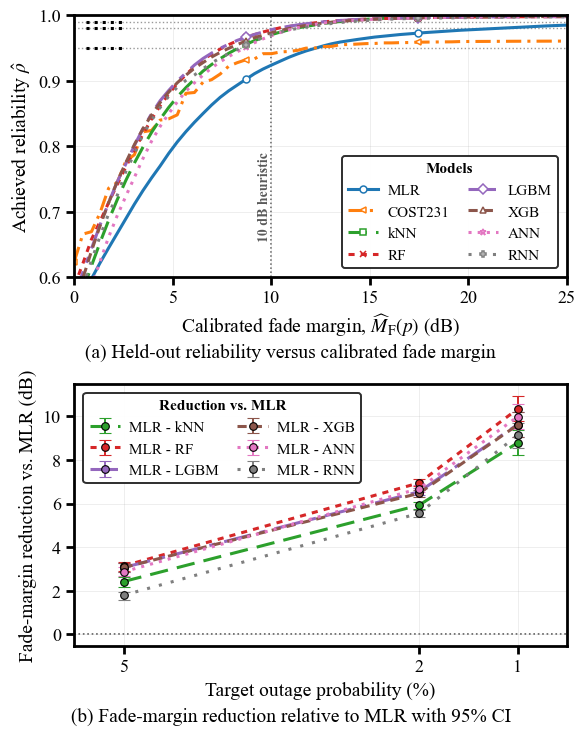

In [31]:
# Plot of the two key analyses combined into one wide top/bottom figure:
# (a) Held-out PDR vs fade margin (FM)
# (b) Fade-margin reduction relative to MLR with 95% CI

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

HEURISTIC_FM_DB = float(globals().get("HEURISTIC_FM_DB", 10.0))
SHOW_HEURISTIC_VLINE_A = True

legend_map = {"MLR": "MLR", "COST 231 MWM": "COST231", "KNN": "kNN", "RF": "RF", "LightGBM": "LGBM", "XGBoost": "XGB", "ANN": "ANN", "RNN": "RNN"}

style_map = {
    "MLR": dict(ls="-", dashes=None, marker="o"),
    "COST 231 MWM": dict(ls="-.", dashes=(5, 2, 1, 2), marker="<"),
    "KNN": dict(ls="--", dashes=(6, 3), marker="s"),
    "RF": dict(ls=":", dashes=(2, 2), marker="x"),
    "LightGBM": dict(ls="-.", dashes=(9, 3, 2, 3), marker="D"),
    "XGBoost": dict(ls="--", dashes=(3, 2), marker="^"),
    "ANN": dict(ls="-", dashes=(1, 2), marker="*"),
    "RNN": dict(ls=":", dashes=(1, 3), marker="P"),
}
ORDER = ["MLR", "COST 231 MWM", "KNN", "RF", "LightGBM", "XGBoost", "ANN", "RNN"]

tick_fontsize = 13
axis_labelsize = 14
legend_fontsize = 11
ab_fontsize = 14

def p_as_dec(p):
    p = float(p)
    return p / 100.0 if p > 1.0 else p

P_GRID_DEC = sorted([p_as_dec(p) for p in P_GRID], reverse=True)

fm = fm_table.copy()
fm["p_dec"] = fm["p"].astype(float)
fm.loc[fm["p_dec"] > 1.0, "p_dec"] = fm.loc[fm["p_dec"] > 1.0, "p_dec"] / 100.0

def pdr_curve(eps_test, fm_min=0.0, fm_max=None, num=160):
    eps = np.asarray(eps_test, float)
    if fm_max is None:
        fm_max = np.percentile(eps, 99.9)
    grid = np.linspace(fm_min, fm_max, num=num)
    pdr = np.array([np.mean(eps <= m) for m in grid], float)
    return grid, pdr

def row_for(model, p_dec):
    mask = (fm["model"] == model) & np.isclose(fm["p_dec"].to_numpy(), p_dec)
    r = fm[mask]
    if r.empty:
        return None
    return {"fm": float(r["fm_sel"].iloc[0]), "lo": float(r["fm_sel_lo"].iloc[0]), "hi": float(r["fm_sel_hi"].iloc[0])}

eps_all = [np.asarray(v, float) for v in test_residuals.values()]
shared_fm_max = max(float(HEURISTIC_FM_DB), *[float(np.percentile(eps, 99.9)) for eps in eps_all])

curves = {}
for fam, eps_test in test_residuals.items():
    fm_grid, pdr_grid = pdr_curve(eps_test, fm_min=0.0, fm_max=shared_fm_max, num=160)
    curves[fam] = {"fm_grid": fm_grid, "pdr_grid": pdr_grid}

fig, (axA, axB) = plt.subplots(2, 1, figsize=(6, 7.2))

# (a) Held-out PDR vs FM
line_handles = {}
for fam in ORDER:
    if fam not in curves:
        continue
    st = style_map.get(fam, {})
    ln, = axA.plot(curves[fam]["fm_grid"], curves[fam]["pdr_grid"], linewidth=2.2, linestyle=st.get("ls", "-"), marker=st.get("marker", None), markevery=20, markersize=5.0, markerfacecolor="white", markeredgewidth=1.1, label=legend_map.get(fam, fam), zorder=2)
    ln.set_markeredgecolor(ln.get_color())
    if st.get("dashes") is not None:
        ln.set_dashes(st["dashes"])
    line_handles[fam] = ln

ISO_CAP_X0, ISO_CAP_X1 = 0.6, 2.6
for p_dec in P_GRID_DEC:
    y = 1.0 - p_dec
    axA.axhline(y, linestyle=":", linewidth=1.0, color="0.6", zorder=0.8)
    axA.plot([ISO_CAP_X0, ISO_CAP_X1], [y, y], linestyle=":", linewidth=2.2, color="black", solid_capstyle="round", zorder=3)

if SHOW_HEURISTIC_VLINE_A:
    axA.axvline(HEURISTIC_FM_DB, linestyle=":", linewidth=1.1, color="0.35", zorder=1)
    axA.text(HEURISTIC_FM_DB - 0.65, 0.655, f"{HEURISTIC_FM_DB:.0f} dB heuristic", fontsize=10, fontweight="bold", color="0.35", rotation=90, ha="left", va="bottom", clip_on=True)

axA.set_xlabel(r"Calibrated fade margin, $\widehat{M}_{\mathrm{F}}(p)$ (dB)", fontsize=axis_labelsize)
axA.set_ylabel(r"Achieved reliability $\hat{\rho}$", fontsize=axis_labelsize)
axA.set_xlim(0.0, 25)
axA.set_ylim(0.60, 1.0)
axA.tick_params(axis="both", labelsize=tick_fontsize)
axA.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

legA = axA.legend(title="Models", loc="lower right", ncol=2, fontsize=legend_fontsize, title_fontproperties={"weight": "bold", "size": legend_fontsize}, frameon=True, columnspacing=1.2, handletextpad=0.6, borderaxespad=0.6)
legA.get_frame().set_facecolor("#ffffff")
legA.get_frame().set_edgecolor("#222222")
legA.get_frame().set_linewidth(1.4)
legA.get_frame().set_alpha(0.95)
legA.set_zorder(10)

# (b) Fade-margin reduction vs MLR
BASELINE_MODEL = "MLR"
comparisons = [
    #(BASELINE_MODEL, "COST 231 MWM", "MLR - COST231"),
    (BASELINE_MODEL, "KNN", "MLR - kNN"),
    (BASELINE_MODEL, "RF", "MLR - RF"),
    (BASELINE_MODEL, "LightGBM", "MLR - LGBM"),
    (BASELINE_MODEL, "XGBoost", "MLR - XGB"),
    (BASELINE_MODEL, "ANN", "MLR - ANN"),
    (BASELINE_MODEL, "RNN", "MLR - RNN"),
]

for A, B, label in comparisons:
    xs, ds, err_lo, err_hi = [], [], [], []
    for p_dec in P_GRID_DEC:
        rA = row_for(A, p_dec)
        rB = row_for(B, p_dec)
        if (rA is None) or (rB is None):
            continue
        d = rA["fm"] - rB["fm"]
        d_lo = rA["lo"] - rB["hi"]
        d_hi = rA["hi"] - rB["lo"]
        xs.append(p_dec * 100.0)
        ds.append(d)
        err_lo.append(max(d - d_lo, 0.0))
        err_hi.append(max(d_hi - d, 0.0))

    if not xs:
        continue

    comp_model = B if A == BASELINE_MODEL else A
    c = line_handles[comp_model].get_color() if comp_model in line_handles else None
    st = style_map.get(comp_model, {})
    eb = axB.errorbar(xs, ds, yerr=[err_lo, err_hi], marker="o", markersize=5.5, markerfacecolor=c, markeredgecolor="black", 
                      markeredgewidth=0.8, linewidth=2.2, linestyle=st.get("ls", "-"), elinewidth=1.4, capsize=4, capthick=1.4, color=c, label=label, zorder=3)
    if st.get("dashes") is not None:
        try:
            eb.lines[0].set_dashes(st["dashes"])
        except Exception:
            pass

axB.axhline(0.0, linestyle=":", linewidth=1.2, color="0.35", zorder=1)

xt = [p * 100.0 for p in P_GRID_DEC]
axB.set_xticks(xt)
axB.set_xlim(max(xt) + 0.5, min(xt) - 0.5)
axB.set_xlabel("Target outage probability (%)", fontsize=axis_labelsize)
axB.set_ylabel(r"Fade-margin reduction vs. MLR (dB)",  fontsize=axis_labelsize)
#axB.set_ylabel(r"Fade-margin reduction vs. MLR, $M_{\mathrm{F},\mathrm{MLR}}(p)-M_{\mathrm{F},\mathrm{model}}(p)$ (dB)", 
#               fontsize=axis_labelsize)
axB.tick_params(axis="both", labelsize=tick_fontsize)
axB.grid(True, which="both", linewidth=0.5, alpha=0.3, zorder=0)

legB = axB.legend(title="Reduction vs. MLR", loc="upper left", ncol=2, fontsize=legend_fontsize, title_fontproperties={"weight": "bold", "size": legend_fontsize}, 
                  frameon=True, columnspacing=1.2, handletextpad=0.6, borderaxespad=0.6)
legB.get_frame().set_facecolor("#ffffff")
legB.get_frame().set_edgecolor("#222222")
legB.get_frame().set_linewidth(1.4)
legB.get_frame().set_alpha(0.95)
legB.set_zorder(10)

for ax in (axA, axB):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor("black")
    ax.tick_params(which="both", width=2, length=6)

plt.tight_layout(h_pad=3.3)
fig.text(0.5, 0.515, "(a) Held-out reliability versus calibrated fade margin", ha="center", va="top", fontsize=ab_fontsize, fontfamily="Times New Roman", fontweight="normal")
fig.text(0.5, -0.015, "(b) Fade-margin reduction relative to MLR with 95% CI", ha="center", va="bottom", fontsize=ab_fontsize, fontfamily="Times New Roman", fontweight="normal")

plt.savefig("Figures/pdr_fade_margin_and_reduction_wide.png", dpi=1200, bbox_inches="tight")
plt.show()

#### Display Summaries + Paper Snippet

In [8]:
# Display tables
display(fm_table)
display(validation_df)

def paper_snippet(model_name, p=0.01):
    sub = fm_table[(fm_table["model"] == model_name) & (fm_table["p"] == p)]
    if sub.empty:
        return f"[{model_name}] No FM row for p={p}."
    sub = sub.iloc[0]
    val = validation_df[(validation_df["model"] == model_name) & (validation_df["p_target"] == p)]
    if val.empty:
        return f"[{model_name}] No validation row for p={p}."
    val = val.iloc[0]
    fm = sub["fm_sel"]; lo = sub["fm_sel_lo"]; hi = sub["fm_sel_hi"]; est = sub["selected"]
    ach_p = val["achieved_outage"]; ach_pdr = val["achieved_reliability"]
    return (
        f"FM calibration for {model_name}: For p={p:.2%}, we obtain FM{int((1-p)*100)} = {fm:.2f} dB "
        f"[95% CI: {lo:.2f}, {hi:.2f}] using {est}. On held-out test, achieved outage "
        f"is {ach_p:.2%} (PDR={ach_pdr:.2%})."
    )

for fam in ["MLR", "COST 231 MWM", "KNN", "RF", "LightGBM", "XGBoost", "ANN", "RNN"]:
    if fam in fm_table["model"].unique():
        print(paper_snippet(fam, p=0.01))

,model,p,block_len,fm_emp,fm_emp_lo,fm_emp_hi,param_name,fm_param,param_lo,param_hi,param_aic,param_bic,selected,fm_sel,fm_sel_lo,fm_sel_hi,estimator_note
0,MLR,0.05,25,12.990381,12.883489,13.080169,gmm(K=3),12.752794,12.709438,12.797159,1.147045e+07,1.147055e+07,empirical,12.990381,12.883489,13.080169,empirical quantile (BC bootstrap)
1,MLR,0.02,25,19.468632,19.318895,19.633383,gmm(K=3),21.592548,21.488213,21.700987,1.147045e+07,1.147055e+07,gmm-tail,21.592548,21.488213,21.700987,gmm tail (K=3; parametric bootstrap CI)
2,MLR,0.01,25,28.049032,27.544516,28.582331,gmm(K=3),28.047654,27.921652,28.176326,1.147045e+07,1.147055e+07,empirical,28.049032,27.544516,28.582331,empirical quantile (BC bootstrap)
3,COST 231 MWM,0.05,25,12.847987,12.763591,13.005167,gmm(K=3),12.342469,12.297582,12.385647,1.149669e+07,1.149679e+07,empirical,12.847987,12.763591,13.005167,empirical quantile (BC bootstrap)
4,COST 231 MWM,0.02,25,42.776445,42.627491,42.784453,gmm(K=3),41.889616,41.606033,42.189572,1.149669e+07,1.149679e+07,empirical,42.776445,42.627491,42.784453,empirical quantile (BC bootstrap)
5,COST 231 MWM,0.01,25,58.104725,57.776158,58.185624,gmm(K=3),54.893872,54.692449,55.128300,1.149669e+07,1.149679e+07,empirical,58.104725,57.776158,58.185624,empirical quantile (BC bootstrap)
6,KNN,0.05,25,10.566667,10.466667,10.700000,gmm(K=3),10.568770,10.534912,10.601930,1.083172e+07,1.083182e+07,empirical,10.566667,10.466667,10.700000,empirical quantile (BC bootstrap)
7,KNN,0.02,25,14.733333,14.533333,14.900000,gmm(K=3),15.663219,15.603598,15.720338,1.083172e+07,1.083182e+07,gmm-tail,15.663219,15.603598,15.720338,gmm tail (K=3; parametric bootstrap CI)
8,KNN,0.01,25,17.700000,17.433333,17.933333,gmm(K=3),19.260501,19.185439,19.331552,1.083172e+07,1.083182e+07,gmm-tail,19.260501,19.185439,19.331552,gmm tail (K=3; parametric bootstrap CI)
9,RF,0.05,25,9.848459,9.739938,9.954552,gmm(K=3),9.990961,9.957322,10.023968,1.042455e+07,1.042465e+07,empirical,9.848459,9.739938,9.954552,empirical quantile (BC bootstrap)


,model,p_target,FM_used,FM_lo,FM_hi,achieved_outage,achieved_reliability,estimator
0,MLR,0.05,12.990381,12.883489,13.080169,0.044149,0.955851,empirical
1,MLR,0.02,21.592548,21.488213,21.700987,0.019891,0.980109,gmm-tail
2,MLR,0.01,28.049032,27.544516,28.582331,0.013474,0.986526,empirical
3,MLR,NaN,10.000000,NaN,NaN,0.076279,0.923721,Heuristic (10.0 dB)
4,COST 231 MWM,0.05,12.847987,12.763591,13.005167,0.047989,0.952011,empirical
5,COST 231 MWM,0.02,42.776445,42.627491,42.784453,0.029531,0.970469,empirical
6,COST 231 MWM,0.01,58.104725,57.776158,58.185624,0.010320,0.989680,empirical
7,COST 231 MWM,NaN,10.000000,NaN,NaN,0.058669,0.941331,Heuristic (10.0 dB)
8,KNN,0.05,10.566667,10.466667,10.700000,0.024693,0.975307,empirical
9,KNN,0.02,15.663219,15.603598,15.720338,0.004842,0.995158,gmm-tail


FM calibration for MLR: For p=1.00%, we obtain FM99 = 28.05 dB [95% CI: 27.54, 28.58] using empirical. On held-out test, achieved outage is 1.35% (PDR=98.65%).
FM calibration for COST 231 MWM: For p=1.00%, we obtain FM99 = 58.10 dB [95% CI: 57.78, 58.19] using empirical. On held-out test, achieved outage is 1.03% (PDR=98.97%).
FM calibration for KNN: For p=1.00%, we obtain FM99 = 19.26 dB [95% CI: 19.19, 19.33] using gmm-tail. On held-out test, achieved outage is 0.22% (PDR=99.78%).
FM calibration for RF: For p=1.00%, we obtain FM99 = 17.71 dB [95% CI: 17.65, 17.77] using gmm-tail. On held-out test, achieved outage is 0.36% (PDR=99.64%).
FM calibration for LightGBM: For p=1.00%, we obtain FM99 = 18.42 dB [95% CI: 18.35, 18.49] using gmm-tail. On held-out test, achieved outage is 0.32% (PDR=99.68%).
FM calibration for XGBoost: For p=1.00%, we obtain FM99 = 18.44 dB [95% CI: 18.37, 18.51] using gmm-tail. On held-out test, achieved outage is 0.34% (PDR=99.66%).
FM calibration for ANN: For